# 01_Data Exploration and Baseline Definition

## 1 Objective

This notebook establishes a **clean-image baseline** for image quality and segmentation performance.

It defines regions of interest (ROIs), introduces evaluation metrics, and evaluates a simple Frangi-based segmentation pipeline.  
This baseline serves as a reference for analyzing the effect of **low-dose noise** and **denoising methods** in subsequent notebooks.

## 2 Evaluation Framework

To evaluate image quality and its impact on downstream tasks, four complementary metrics are used:

- **Background SNR (mean(background) / std(background))** → *How strong is the background signal relative to noise?*  
- **CNR (Contrast-to-Noise Ratio)** → *How well can vessels be distinguished from background?*  
- **Dice score (after Frangi segmentation)** → *How well does segmentation overlap with ground truth?*  
- **Precision / Recall** → *What types of segmentation errors occur (false positives vs missed vessels)?*  

This combination enables analysis across multiple levels:

- **noise level** (Background SNR)  
- **contrast / separability level** (CNR)  
- **task performance** (Dice)  
- **error characteristics** (Precision / Recall)  

Together, these metrics provide a structured view of how noise and preprocessing affect both image quality and downstream segmentation behavior.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

import sys
sys.path.append('..')

import importlib
import algorithms.frangi
importlib.reload(algorithms.frangi)
import metrics.snr_cnr 
importlib.reload(metrics.snr_cnr)
import datasets.arcade_dataset 
importlib.reload(datasets.arcade_dataset)

from datasets.arcade_dataset import Sample, ArcadeDataset
from metrics.snr_cnr import compute_snr_cnr, get_bg_mask
from metrics.dice import compute_dice
from algorithms.frangi import apply_frangi



## 3 Dataset Overview
The dataset consists of grayscale X-ray angiography images with corresponding vessel annotations provided as polygon masks.  
These masks are rasterized to obtain binary vessel regions used for analysis and evaluation.
5 samples were excluded from the validation dataset after visual control due to strong frame artifact.


In [2]:
dataset = ArcadeDataset(root_dir="../data", split="val")
print(len(dataset), dataset[0].image.shape, dataset[0].mask.shape)

195 (512, 512) (512, 512)


## 4 Region of Interest (ROI) Definition

To compute meaningful image quality metrics, vessel and background regions are defined as follows:

- **Vessel region**: directly taken from the ground truth (GT) mask  
- **Background region**: defined by excluding:
  - a dilated version of the vessel mask (The vessel mask is dilated before background extraction to avoid boundary regions where partial volume effects and annotation uncertainty may bias noise estimation.)  
  - a border margin (to remove frame artefacts present in some images)  
 
The resulting ROIs are illustrated below:
- Image with GT vessel mask overlay  
- Image with background mask used for SNR/CNR computation  

This ensures a clean separation between signal (vessels) and background noise.

It is important to note that the background ROI may still contain small, unlabeled vessels, as annotations focus on major coronary segments.  
This may bias background statistics and lead to conservative CNR estimates.



In [3]:
def plot_rois(filename, part = "a"):
    ''' 
    Plot vessel and background ROIs for visualization
    '''
    sample = dataset.get_by_filename(filename)
    bg_mask = get_bg_mask(sample.mask)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Figure 1{part}. Sample {filename}: ROI definitions for SNR/CNR computation", fontsize=14)

    # left: image with vessel mask overlay
    axes[0].imshow(sample.image, cmap='gray')
    vessel_overlay = np.zeros((*sample.image.shape, 4))
    vessel_overlay[sample.mask == 1] = [1, 0, 0, 0.3]  # red, semi-transparent
    axes[0].imshow(vessel_overlay)
    axes[0].set_title("Vessel mask")
    axes[0].axis('off')

    # middle: image with background ROI overlay
    axes[1].imshow(sample.image, cmap='gray')
    bg_overlay = np.zeros((*sample.image.shape, 4))
    bg_overlay[bg_mask == 1] = [0, 0, 1, 0.3]  # blue, semi-transparent
    axes[1].imshow(bg_overlay)
    axes[1].set_title("Background ROI")
    axes[1].axis('off')

    
    plt.tight_layout()
    plt.show()
    metrics = compute_snr_cnr(sample.image, sample.mask)
    print(f"For the sample {filename}: SNR={metrics['snr']:.3f}, CNR={metrics['cnr']:.3f}")


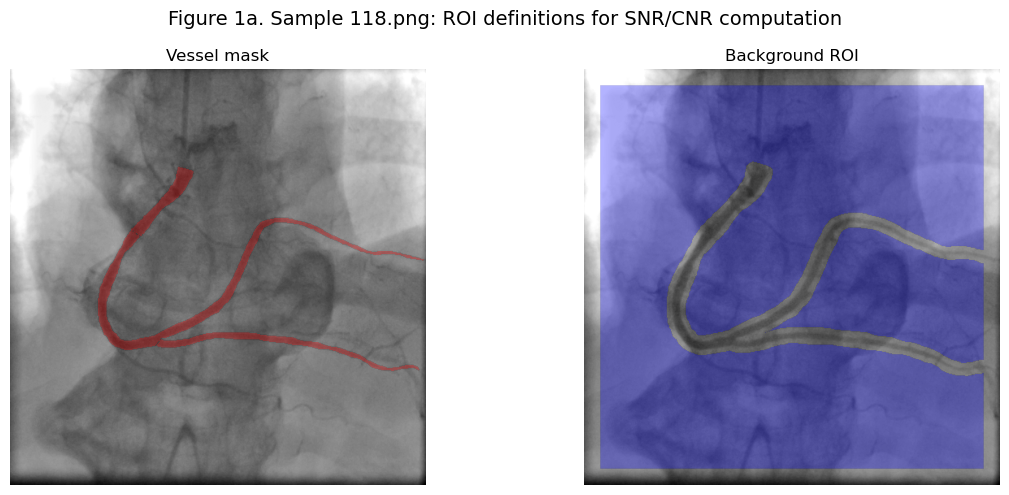

For the sample 118.png: SNR=3.732, CNR=1.158


In [4]:
idx = np.random.randint(0, len(dataset))
sample = dataset[idx]
filename = Path(sample.path).name

plot_rois(filename)

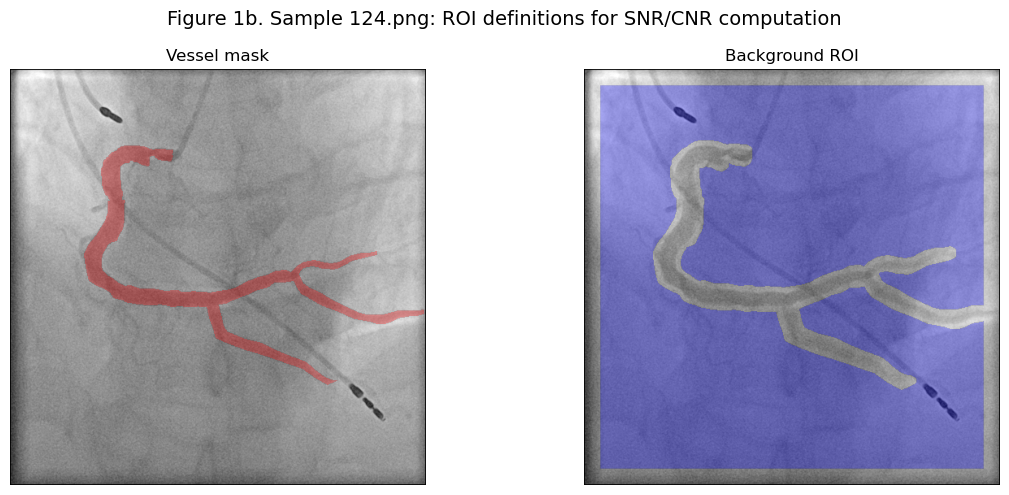

For the sample 124.png: SNR=6.742, CNR=0.761


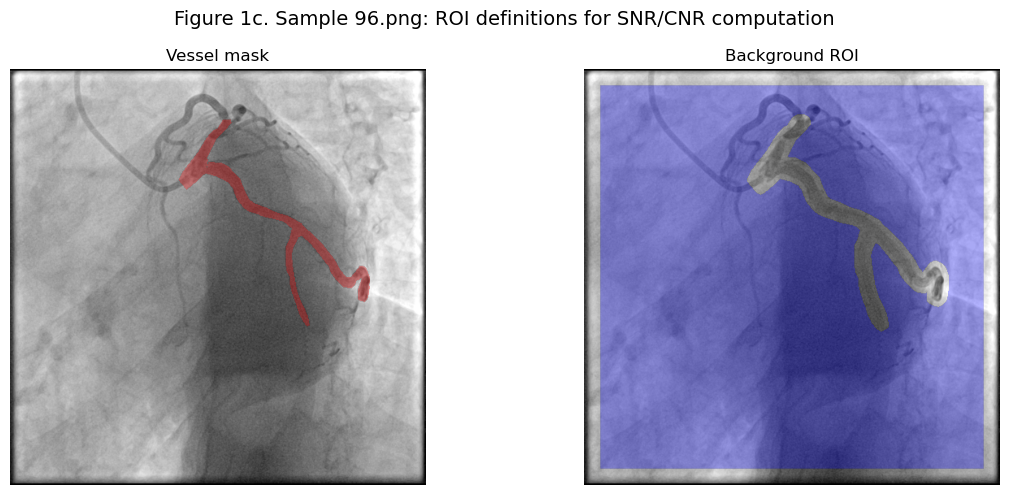

For the sample 96.png: SNR=3.673, CNR=1.057


In [5]:
# hand picked "difficult" samples
#filename2 = "121.png"
filename2= "124.png"
sample2 = dataset.get_by_filename(filename2)
plot_rois(filename2, part = "b")
filename3 = "96.png"
# filename3 = "30.png"
sample3 = dataset.get_by_filename(filename3)
plot_rois(filename3, part = "c")

## 5 Intensity Statistics

First, we plot pixel intensity distributions for vessels (Ground Truth, GT) and background ROIs for a random sample. 

The intensity distributions show limited separation between vessel and background regions, indicating relatively low intrinsic contrast.This suggests that segmentation performance may be sensitive to noise and contrast degradation. 

The vessel intensity distribution suggests the presence of two distinct vessel populations:

- Large proximal vessels (e.g., LAD, proximal RCA), with stronger contrast agent filling and lower intensity (~0.43)  
- Smaller distal vessels, with weaker contrast and higher intensity (~0.50)

Notably, the standard deviation within the vessel ROI reflects not only noise, but also structural heterogeneity (e.g., differences between proximal and distal vessels).  

This highlights that vessel regions are not homogeneous signal regions, which has implications for interpreting SNR-like metrics.


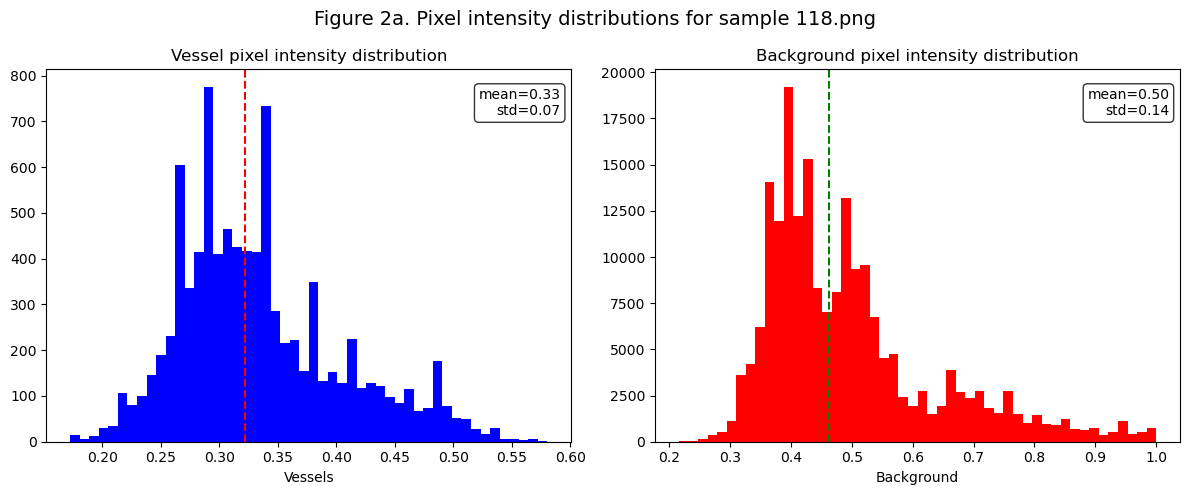

In [6]:
# Background noise statistics
bg_mask = get_bg_mask(sample.mask)
background_pixels = sample.image[bg_mask == 1]
vessel_pixels = sample.image[sample.mask == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Figure 2a. Pixel intensity distributions for sample {filename}", fontsize=14)

# left: vessel
axes[0].hist(vessel_pixels, bins=50, color='blue', label="Vessels")
axes[0].axvline(np.median(vessel_pixels), color='red', linestyle='--', 
                label=f'median={np.median(vessel_pixels):.2f}')
axes[0].set_title("Vessel pixel intensity distribution")
axes[0].set_xlabel("Vessels")

# right: bg
axes[1].hist(background_pixels, bins=50, color='red', label="Background")
axes[1].axvline(np.median(background_pixels), color='green', linestyle='--',
                label=f'median={np.median(background_pixels):.2f}')
axes[1].set_title("Background pixel intensity distribution")
axes[1].set_xlabel("Background")

for ax, values, name in zip(axes, [vessel_pixels, background_pixels], ["Vessels", "Background"]):
    stats = f"mean={np.mean(values):.2f}\nstd={np.std(values):.2f}"
    ax.text(0.98, 0.95, stats, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Figure 2b shows pixel intensity statistics (mean + std) separately for vessel and background regions across the validation set.

These distributions provide insight into:
- vessel-background contrast  -- for nearly all samples background_mean - background_std at least slightly overlaps with vessel_mean+vessel_std making threshold-based signal separation challenging
- variability across images  -- while many images imply decent contrast, for some vessel pixel intensity distribution is entirely within background pixel intensity distribution 

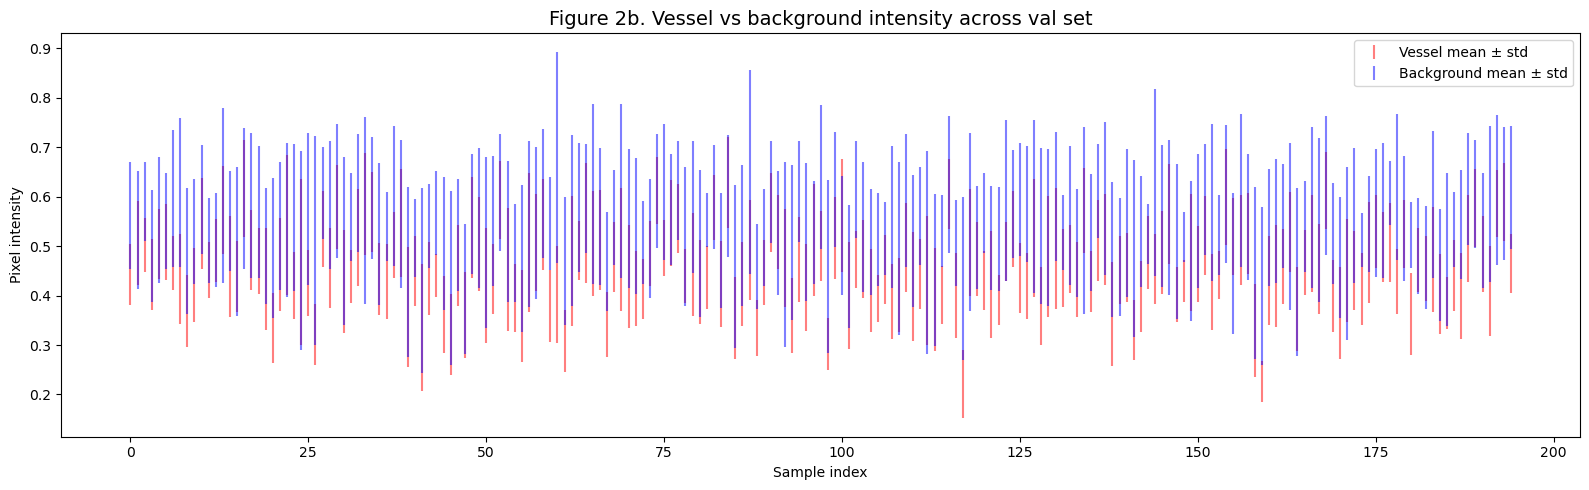

In [7]:
vessel_means, vessel_stds = [], []
bg_means, bg_stds = [], []

for sample in dataset:
    bg_mask = get_bg_mask(sample.mask)
    vessel_pixels = sample.image[sample.mask == 1]
    bg_pixels = sample.image[bg_mask == 1]
    vessel_means.append(vessel_pixels.mean())
    vessel_stds.append(vessel_pixels.std())
    bg_means.append(bg_pixels.mean())
    bg_stds.append(bg_pixels.std())

vessel_means = np.array(vessel_means)
vessel_stds = np.array(vessel_stds)
bg_means = np.array(bg_means)
bg_stds = np.array(bg_stds)

x = np.arange(len(dataset))

fig, ax = plt.subplots(figsize=(16, 5))
ax.errorbar(x, vessel_means, yerr=vessel_stds, fmt='none',
            color='red', alpha=0.5, label='Vessel mean ± std')
ax.errorbar(x, bg_means, yerr=bg_stds, fmt='none',
            color='blue', alpha=0.5, label='Background mean ± std')
ax.set_xlabel("Sample index")
ax.set_ylabel("Pixel intensity")
ax.set_title("Figure 2b. Vessel vs background intensity across val set", fontsize = 14)
ax.legend()
plt.tight_layout()
plt.show()

## 6 Image Quality Metrics

Using the defined ROIs, SNR and CNR are computed for each image.
- Background SNR (mean(background) / std(background)) → reflects overall noise level in the image  
- CNR → measures vessel-background separability and is directly relevant for segmentation

Histograms of these metrics across the dataset (Figure 3) show:
- Background SNR values are generally high, indicating relatively low noise levels in the dataset
- Some samples exhibit particularly low CNR values, which may be influenced by residual frame artefacts or imperfect ROI definition. More aggressive framing could be used or they could be disregarded from the val set 
- variability in image quality  


The distributions indicate variability in image quality across the dataset.  
In particular, relatively low CNR values suggest that vessel-background separation is limited, which may impact segmentation robustness.


In [8]:
val_metrics = {"snr":[], "cnr": []}
for sample in dataset:
    metrics = compute_snr_cnr(sample.image, sample.mask, margin = 50)
    val_metrics["snr"].append(metrics["snr"])
    val_metrics["cnr"].append(metrics["cnr"])

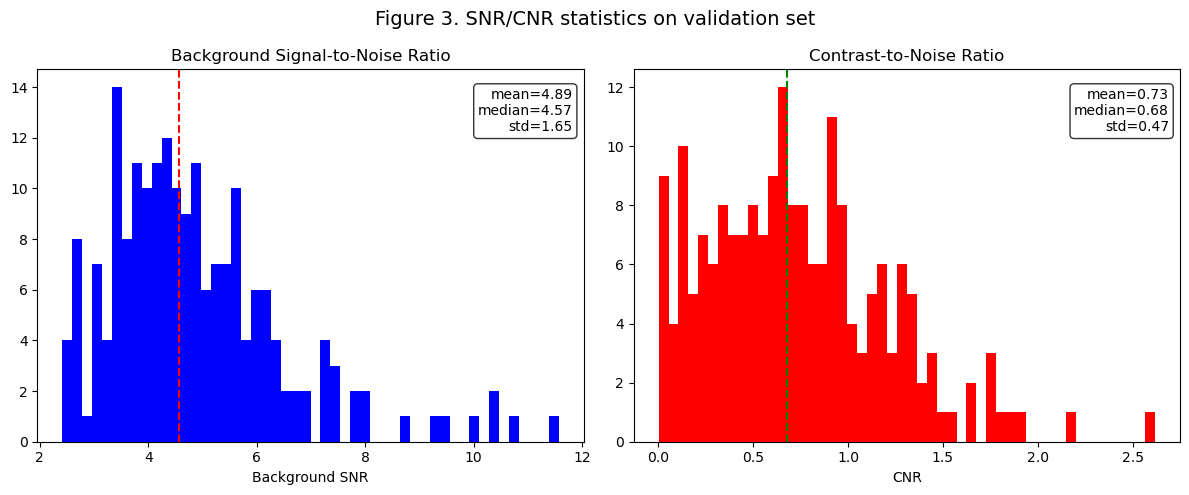

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Figure 3. SNR/CNR statistics on validation set", fontsize=14)

# left: SNR
axes[0].hist(val_metrics["snr"], bins=50, color='blue', label="SNR")
axes[0].axvline(np.median(val_metrics["snr"]), color='red', linestyle='--', 
                label=f'median={np.median(val_metrics["snr"]):.2f}')
axes[0].set_title("Background Signal-to-Noise Ratio")
axes[0].set_xlabel("Background SNR")

# right: CNR
axes[1].hist(val_metrics["cnr"], bins=50, color='red', label="CNR")
axes[1].axvline(np.median(val_metrics["cnr"]), color='green', linestyle='--',
                label=f'median={np.median(val_metrics["cnr"]):.2f}')
axes[1].set_title("Contrast-to-Noise Ratio")
axes[1].set_xlabel("CNR")

for ax, values, name in zip(axes, [val_metrics["snr"],val_metrics["cnr"]], ["SNR", "CNR"]):
    stats = f"mean={np.mean(values):.2f}\nmedian={np.median(values):.2f}\nstd={np.std(values):.2f}"
    ax.text(0.98, 0.95, stats, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 7 Baseline Segmentation (Frangi Filter)

A baseline vessel segmentation pipeline is defined using the Frangi vesselness filter followed by thresholding and morphological post-processing.

### 7.1 Parameter Optimization

The Frangi filter with subsequent Dice score has several parameters (scale range, gamma, threshold, post-processing) that control:

- sensitivity to vessel size  
- sensitivity to noise  
- trade-off between detection and false positives  

To obtain a meaningful baseline, these parameters are optimized via grid search on a subset of validation images (50 random samples).

This step is not intended to find a universal optimal configuration, but to:

- establish a **strong reference baseline** on clean images  
- understand how parameter choices affect segmentation behavior  
- provide a fixed configuration for comparison in later experiments  

This ensures that subsequent experiments isolate the effect of noise rather than suboptimal parameter choices.

The Dice coefficient is used as the primary task-based metric, as it provides a balanced measure of overlap between predicted and ground truth vessel regions.

While precision and recall can offer additional insight into error types (false positives vs missed vessels), they are not included at this stage in order to keep the baseline evaluation concise. A more detailed analysis of error characteristics is performed in later experiments under low-dose conditions.

In [10]:
import itertools
from tqdm import tqdm

scale_ranges = [[2.0, 10.0], [5.0, 10.0], [5.0, 15.0]]
gammas = [1.0, 2.0, 3.0, 5.0, 10.0]
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
dilate_radii = [0, 1, 2]

results = []
subset_idx = np.random.choice(len(dataset), size=50, replace=False)
subset = [dataset[i] for i in subset_idx]
combinations = list(itertools.product(scale_ranges, gammas, thresholds, dilate_radii))

In [11]:
## precompute vesselness maps for each (scale_range, gamma) combination
vesselness_cache = {}
for scale_range, gamma in tqdm(itertools.product(scale_ranges, gammas),
                                total=len(scale_ranges)*len(gammas),
                                desc="precomputing vesselness"):
    maps = [apply_frangi(sample.image, scale_range=scale_range, gamma=gamma) 
            for sample in subset]
    vesselness_cache[(tuple(scale_range), gamma)] = maps


precomputing vesselness: 100%|██████████| 15/15 [19:03<00:00, 76.23s/it]


In [12]:
## now sweep threshold and dilate_radius cheaply
results = []
for scale_range, gamma, threshold, dilate_radius in itertools.product(
    scale_ranges, gammas, thresholds, dilate_radii
):
    maps = vesselness_cache[(tuple(scale_range), gamma)]
    dice_scores = [compute_dice(v, subset[i].mask, threshold=threshold,
                                dilate_radius=dilate_radius)[2]
                   for i, v in enumerate(maps)]
    results.append({
        "scale_range": scale_range,
        "gamma": gamma,
        "threshold": threshold,
        "dilate_radius": dilate_radius,
        "mean_dice": np.mean(dice_scores),
    })

best = max(results, key=lambda x: x["mean_dice"])
print(f"Best: {best}")


Best: {'scale_range': [5.0, 10.0], 'gamma': 2.0, 'threshold': 0.1, 'dilate_radius': 1, 'mean_dice': np.float64(0.545144840359889)}


The optimal configuration favors larger scales and relatively low gamma, indicating that vessel structures are best captured at moderate-to-large scales with high sensitivity in clean images.

In [13]:
import json

with open("../algorithms/frangi_dice_params.json", "w") as f:
    json.dump({k: v for k, v in best.items() if k != "mean_dice"}, f, indent=2)
print("Saved Frangi params:", best)


Saved Frangi params: {'scale_range': [5.0, 10.0], 'gamma': 2.0, 'threshold': 0.1, 'dilate_radius': 1, 'mean_dice': np.float64(0.545144840359889)}


In [14]:
# get Dice for val set with best configuration
val_metrics["dice"] = []
for sample in dataset:
    v = apply_frangi(sample.image, scale_range=best["scale_range"], gamma=best["gamma"])
    _, _, dice = compute_dice(v, sample.mask, dilate_radius=best["dilate_radius"], threshold=best["threshold"])
    val_metrics["dice"].append(dice)


The Dice scores in Figure 5 indicate moderate segmentation performance, reflecting both the simplicity of the pipeline and differences between Frangi output and ground truth annotations.

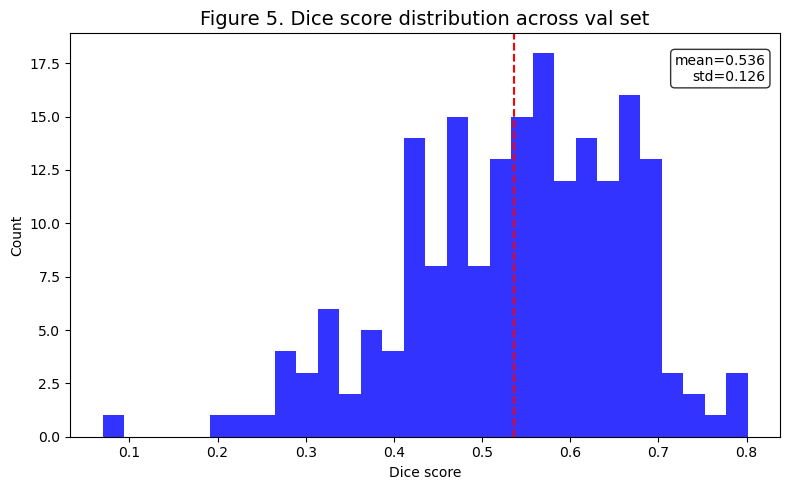

In [15]:
dice_scores = val_metrics["dice"]
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(dice_scores, bins=30, color='blue', alpha=0.8)
ax.axvline(np.mean(dice_scores), color='red', linestyle='--')
ax.text(0.98, 0.95,
        f"mean={np.mean(dice_scores):.3f}\nstd={np.std(dice_scores):.3f}",
        transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel("Dice score")
ax.set_ylabel("Count")
ax.set_title("Figure 5. Dice score distribution across val set", fontsize = 14)
plt.tight_layout()
plt.show()

In [16]:
from IPython.display import Markdown, display
display(Markdown(
        f"## Best Configuration  \n"
        f"Scale range: {best["scale_range"]}  \n"
        f"gamma: {best["gamma"]}  \n"
        f"threshold: {best["threshold"]}  \n"
        f"dilation radious: {best["dilate_radius"]}  \n"
        f"This configuration achieves a mean Dice score of approximately \
            **{np.mean(dice_scores):.3f}** on clean images."))




## Best Configuration  
Scale range: [5.0, 10.0]  
gamma: 2.0  
threshold: 0.1  
dilation radious: 1  
This configuration achieves a mean Dice score of approximately             **0.536** on clean images.

## 7.2 Qualitative Results

Example visualizations compare:
- Ground truth vessel masks  
- Predicted segmentation from the Frangi-based pipeline  
for few samples.

Main observations:
- Frangi enhances vessel-like structures effectively 
- The exclusion of certain large vessels in the ground truth annotations (due to limited clinical relevance) introduces systematic discrepancies between segmentation and GT, which contributes to lower Dice scores


In [17]:
def plot_frangi(filename, sample, part = "a"):
    frangi_vessel = apply_frangi(sample.image, scale_range=(5, 10), gamma = 2.0)
    precision, recall, dice, pred = compute_dice(frangi_vessel, sample.mask, return_map=True, dilate_radius=1, threshold=0.25)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Figure 6{part}. Frangi segmentation for task-based evaluation for sample {filename}", fontsize=14)

    axes[0].imshow(sample.image, cmap = "grey")
    frangi_overlay = np.zeros((*sample.image.shape, 4))
    frangi_overlay[..., 0] = frangi_vessel  # red channel
    frangi_overlay[..., 3] = (frangi_vessel > 0) * 0.5  # 50% transparent where vesselness > 0
    axes[0].imshow(frangi_overlay)
    #axes[0].imshow(frangi_vessel, cmap = "Reds", alpha = 0.3)
    axes[0].set_title("Image + Frangi segmentation output")
    axes[0].axis('off')
    

    axes[1].imshow(sample.image, cmap = "grey")
    pred_overlay = np.zeros((*sample.image.shape, 4))
    pred_overlay[pred == 1] = [1, 0, 0, 0.3]  # red, semi-transparent
    vessel_overlay = np.zeros((*sample.image.shape, 4))
    vessel_overlay[sample.mask == 1] = [0, 0, 1, 0.3]  # blue, semi-transparent
    axes[1].imshow(vessel_overlay)
    axes[1].imshow(pred_overlay)
    axes[1].set_title(f"Image + binary Frangi mask (red) + GT mask (blue). Dice score {dice:.2f}")
    axes[1].axis('off')
    plt.show()

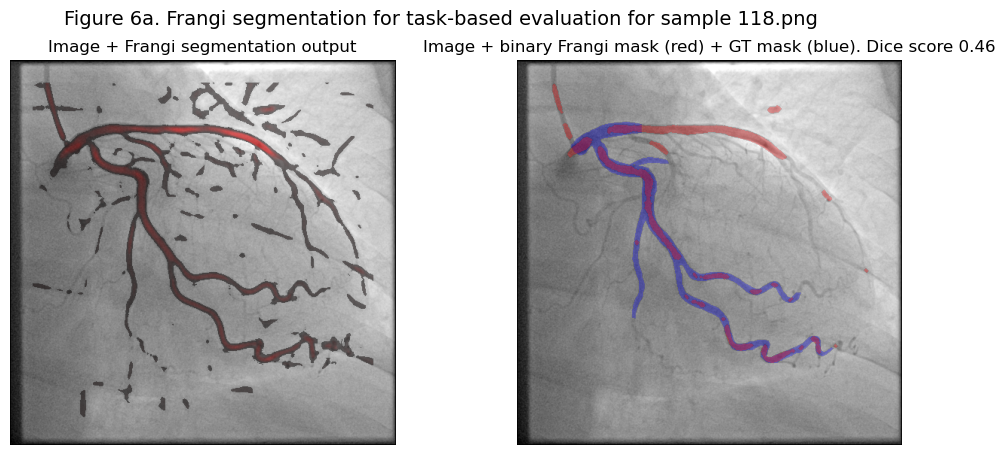

In [18]:
plot_frangi(filename, sample, part = "a")

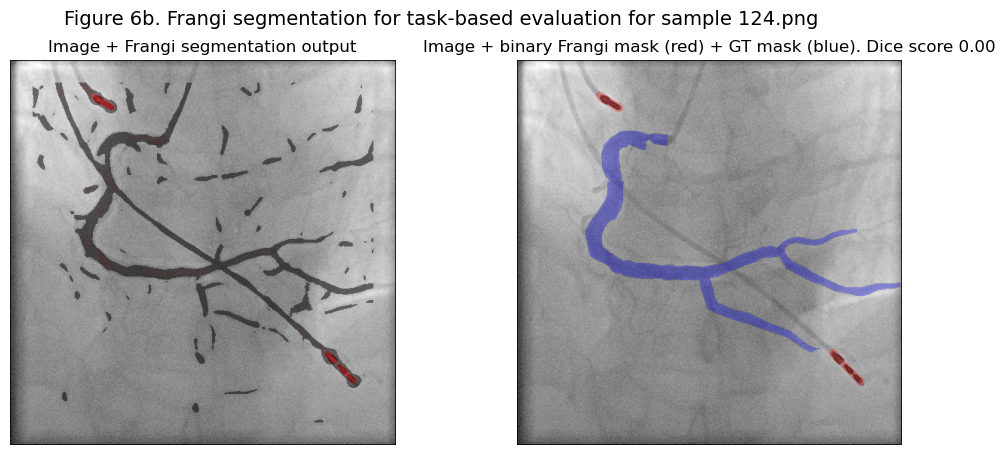

In [19]:
plot_frangi(filename2, sample2, part = "b")

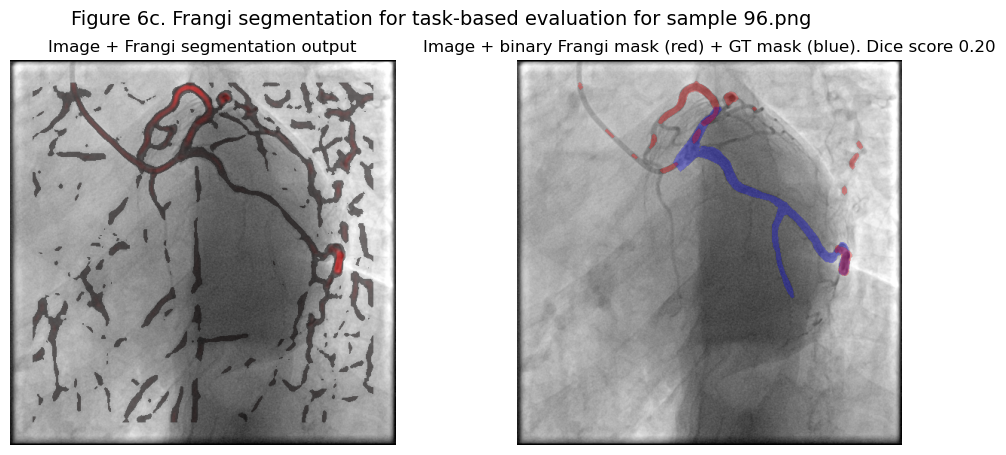

In [20]:
plot_frangi(filename3, sample3, part = "c")

## 8 Summary

- Background SNR and CNR provide complementary measures of image quality  
- The dataset exhibits limited vessel-background contrast, making segmentation non-trivial  
- A Frangi-based pipeline achieves moderate performance (Dice ≈ 0.54) on clean images  
- The segmentation pipeline is intentionally fixed and will be used as a baseline to study the impact of noise and denoising  

This baseline establishes a controlled reference for analyzing how image degradation affects downstream segmentation performance.